# Abbiategrasso: raccolta differenziata e costo del servizio rifiuti

Quarto filone locale della repo.

Obiettivo:
- leggere la posizione di Abbiategrasso su raccolta differenziata (%) e costo del servizio per abitante
- confrontarla con gli stessi comuni gia' usati nel benchmark locale
- leggere il trend 2021-2024 per Abbiategrasso

Fonte: ISPRA Catasto Rifiuti Urbani, elaborazione DataCivicLab (`ispra-ru-costi-kg`).
Anno di riferimento benchmark: 2023.
Trend: 2021-2024.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

project_root = Path.cwd().resolve().parent
data_path_bmark = project_root / 'data' / 'abbiategrasso_rifiuti_benchmark_2023.csv'
data_path_trend = project_root / 'data' / 'abbiategrasso_rifiuti_trend.csv'
figures_path = project_root / 'figures'
figures_path.mkdir(exist_ok=True)

assert data_path_bmark.exists(), data_path_bmark
assert data_path_trend.exists(), data_path_trend

bmark = pd.read_csv(data_path_bmark)
trend = pd.read_csv(data_path_trend)

bmark['comune_label'] = bmark['comune'].str.title()
trend['comune_label'] = trend['comune'].str.title()

bmark.head()

,anno,comune,provincia,popolazione,percentuale_rd,kg_ru_per_abitante_calc,ctot_euro_ab,crd_euro_ab,crt_euro_ab,comune_label
0,2023,CORBETTA,Milano,18934,84.84,398.45,NaN,NaN,NaN,Corbetta
1,2023,CESANO BOSCONE,Milano,23395,76.14,454.09,114.15,25.13,14.63,Cesano Boscone
2,2023,MAGENTA,Milano,24598,72.84,426.69,134.39,44.12,10.05,Magenta
3,2023,ABBIATEGRASSO,Milano,32629,71.39,406.68,146.76,32.76,16.01,Abbiategrasso
4,2023,BUCCINASCO,Milano,26664,70.32,542.62,123.70,21.67,11.27,Buccinasco


## 1. Raccolta differenziata % — benchmark 2023

Nove comuni del Sud Ovest milanese e dintorni.
Dati ISPRA disponibili per tutti.
Abbiategrasso si colloca nel gruppo medio-alto.

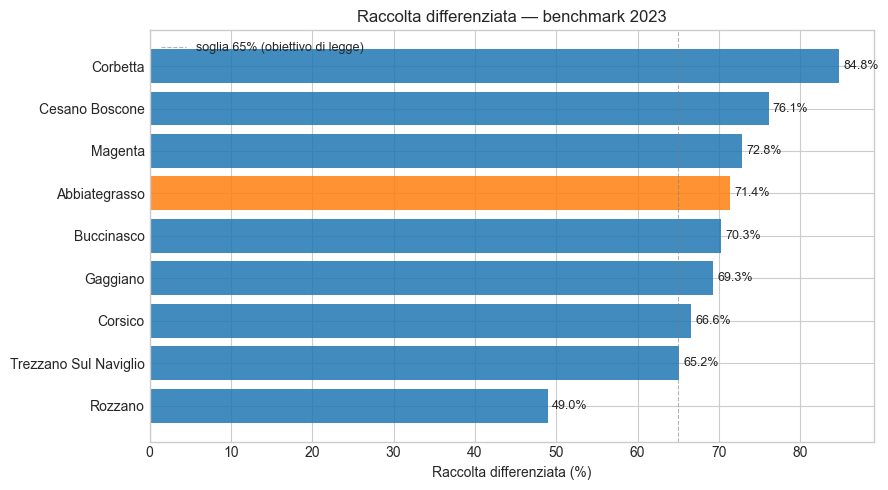

In [2]:
rd_df = bmark.sort_values('percentuale_rd', ascending=True)
colors = ['tab:orange' if c == 'ABBIATEGRASSO' else 'tab:blue' for c in rd_df['comune']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rd_df['comune_label'], rd_df['percentuale_rd'], color=colors, alpha=0.85)
ax.axvline(65, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='soglia 65% (obiettivo di legge)')
ax.set_xlabel('Raccolta differenziata (%)')
ax.set_title('Raccolta differenziata — benchmark 2023')
ax.legend(fontsize=9)
for bar, val in zip(bars, rd_df['percentuale_rd']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
fig.savefig(figures_path / 'abbiategrasso_rifiuti_rd_benchmark_2023.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Costo totale per abitante — benchmark 2023

Solo i comuni con dati disponibili nel mart costi ISPRA: 6 comuni.
Corbetta, Trezzano sul Naviglio e Rozzano non riportano i dati di costo nell'annualita' 2023.

Abbiategrasso ha il costo piu' alto del gruppo.

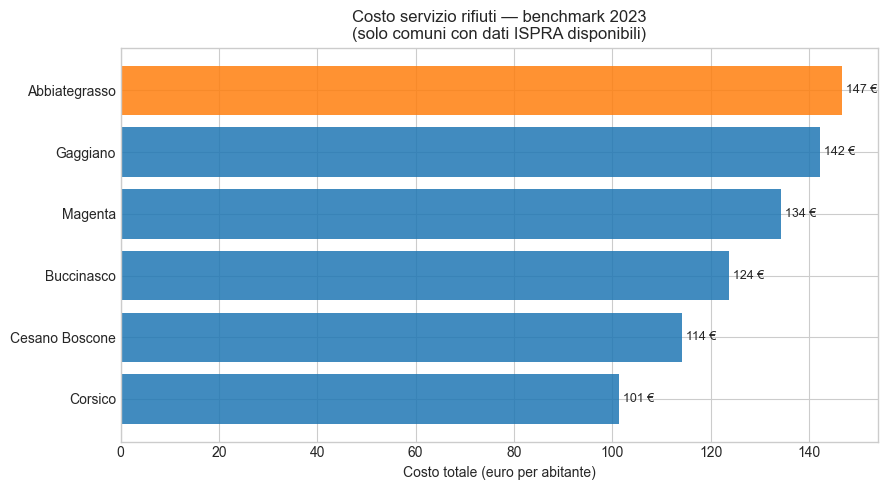

In [3]:
cost_df = bmark.dropna(subset=['ctot_euro_ab']).sort_values('ctot_euro_ab', ascending=True)
colors_c = ['tab:orange' if c == 'ABBIATEGRASSO' else 'tab:blue' for c in cost_df['comune']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cost_df['comune_label'], cost_df['ctot_euro_ab'], color=colors_c, alpha=0.85)
ax.set_xlabel('Costo totale (euro per abitante)')
ax.set_title('Costo servizio rifiuti — benchmark 2023\n(solo comuni con dati ISPRA disponibili)')
for bar, val in zip(bars, cost_df['ctot_euro_ab']):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} €', va='center', fontsize=9)
plt.tight_layout()
fig.savefig(figures_path / 'abbiategrasso_rifiuti_costo_benchmark_2023.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Trend Abbiategrasso 2021–2024

La raccolta differenziata ha toccato il massimo nel 2022 (73.7%) ed e' poi scesa.
Il costo ha seguito il percorso inverso: minimo nel 2022, poi rimbalzo verso i livelli 2021.

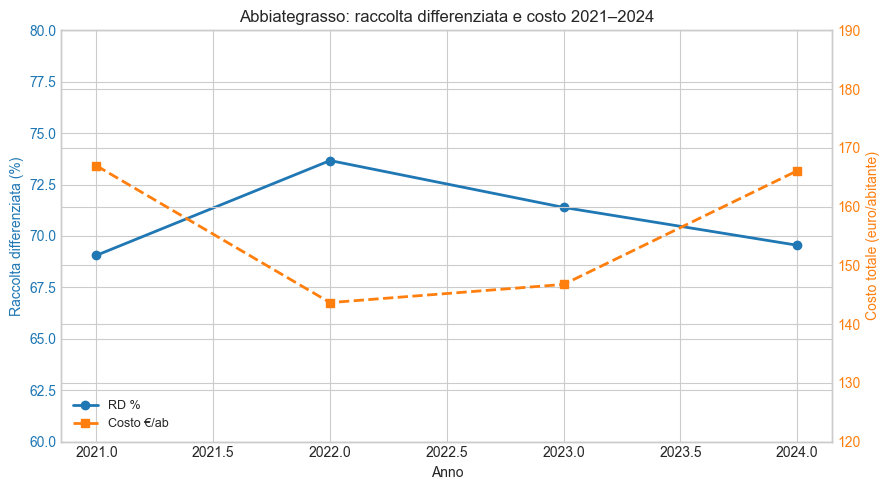

In [4]:
fig, ax1 = plt.subplots(figsize=(9, 5))

color_rd = 'tab:blue'
color_cost = 'tab:orange'

ax1.set_xlabel('Anno')
ax1.set_ylabel('Raccolta differenziata (%)', color=color_rd)
ax1.plot(trend['anno'], trend['percentuale_rd'], color=color_rd, marker='o', linewidth=2, label='RD %')
ax1.tick_params(axis='y', labelcolor=color_rd)
ax1.set_ylim(60, 80)

ax2 = ax1.twinx()
ax2.set_ylabel('Costo totale (euro/abitante)', color=color_cost)
ax2.plot(trend['anno'], trend['ctot_euro_ab'], color=color_cost, marker='s', linewidth=2, linestyle='--', label='Costo €/ab')
ax2.tick_params(axis='y', labelcolor=color_cost)
ax2.set_ylim(120, 190)

ax1.set_title('Abbiategrasso: raccolta differenziata e costo 2021–2024')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9)

plt.tight_layout()
fig.savefig(figures_path / 'abbiategrasso_rifiuti_trend_2021_2024.png', dpi=150, bbox_inches='tight')
plt.show()

## Note operative

**Dati mancanti nel mart costi:** Corbetta, Trezzano sul Naviglio e Rozzano non hanno dati di costo disponibili
nelle annualita' analizzate. Non e' chiaro se per mancato aggiornamento ISPRA o per scelta del comune.

**Costo 2024:** il dato 2024 per Abbiategrasso e' disponibile nel mart ma potrebbe essere una stima provvisoria;
ISPRA aggiorna i dati con un anno di ritardo.

**Provenance:** CSV bundled estratti dal mart `ispra-ru-costi-kg` di [DataCivicLab](https://github.com/dataciviclab).
Fonte primaria: ISPRA Catasto Rifiuti Urbani.